## Importing the Data

In [153]:
import pandas as pd

df = pd.read_csv("C:/Users/ganil/Downloads/sp500_stocks.csv")

In [154]:
df.shape

(1891536, 8)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


### Converting Date to datetime

In [156]:
df['Date'] = pd.to_datetime(df['Date'])

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date       datetime64[ns]
 1   Symbol     object        
 2   Adj Close  float64       
 3   Close      float64       
 4   High       float64       
 5   Low        float64       
 6   Open       float64       
 7   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 115.5+ MB


### Checking the null values

In [158]:
df[['Close', 'Volume']].isnull().sum()

Close     1273705
Volume    1273705
dtype: int64

In [159]:
## droping rows where Close or Volume is null
df.dropna(subset=('Close', 'Volume'), inplace=True)

In [160]:
df.shape

(617831, 8)

### Checking for duplicate values

In [161]:
df.drop_duplicates()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0
...,...,...,...,...,...,...,...,...
1876459,2024-12-16,XYL,120.779999,120.779999,122.570000,120.000000,120.720001,1515900.0
1876460,2024-12-17,XYL,120.769997,120.769997,121.760002,119.730003,119.730003,2009200.0
1876461,2024-12-18,XYL,116.919998,116.919998,121.559998,116.879997,120.790001,1638500.0
1876462,2024-12-19,XYL,116.430000,116.430000,118.919998,116.129997,117.440002,1708000.0


In [162]:
df.sort_values(by=['Symbol', 'Date'])

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
12058,2013-01-02,ABBV,21.629181,35.119999,35.400002,34.099998,34.919998,13767900.0
12059,2013-01-03,ABBV,21.450581,34.830002,35.000000,34.160000,35.000000,16739300.0
12060,2013-01-04,ABBV,21.179594,34.389999,34.889999,34.250000,34.619999,21372100.0
12061,2013-01-07,ABBV,21.222700,34.459999,35.450001,34.150002,34.150002,17897100.0
12062,2013-01-08,ABBV,20.760809,33.709999,34.639999,33.360001,34.290001,17863300.0
...,...,...,...,...,...,...,...,...
1876459,2024-12-16,XYL,120.779999,120.779999,122.570000,120.000000,120.720001,1515900.0
1876460,2024-12-17,XYL,120.769997,120.769997,121.760002,119.730003,119.730003,2009200.0
1876461,2024-12-18,XYL,116.919998,116.919998,121.559998,116.879997,120.790001,1638500.0
1876462,2024-12-19,XYL,116.430000,116.430000,118.919998,116.129997,117.440002,1708000.0


In [163]:
df = df.reset_index()

In [164]:
df.drop(columns=['index'], inplace=True)

In [165]:
df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
1,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
2,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
4,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0


### Checking for anomalies

In [166]:
df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,617831,617831.000000,617831.000000,617831.000000,617831.000000,617831.000000,6.178310e+05
mean,2017-08-28 16:17:09.205722112,79.672357,87.471540,88.417844,86.480997,87.460302,9.347125e+06
min,2010-01-04 00:00:00,0.203593,0.222000,0.226250,0.216250,0.218000,0.000000e+00
25%,2013-12-26 00:00:00,26.572459,32.700001,33.060001,32.299999,32.689999,1.144000e+06
50%,2017-09-27 00:00:00,49.821613,59.139999,59.720001,58.500000,59.119999,2.453400e+06
75%,2021-05-18 00:00:00,94.831036,105.019997,106.129997,103.889999,105.000000,5.657850e+06
max,2024-12-20 00:00:00,1702.530029,1702.530029,1714.750000,1696.900024,1706.400024,3.692928e+09
std,NaN,102.742931,104.521901,105.684113,103.300770,104.519845,4.771669e+07


### Extracting year, month, quarter as new columns from date

In [167]:
df['Year'] = df['Date'].dt.year

In [168]:
df['Month'] = df['Date'].dt.month

In [169]:
df['Quarter'] = df['Date'].dt.quarter

In [170]:
df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,Year,Month,Quarter
0,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0,2010,1,1
1,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0,2010,1,1
2,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0,2010,1,1
3,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0,2010,1,1
4,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0,2010,1,1


### Q1 — How many unique stock symbols are in the dataset?

In [171]:
num_symbols = df['Symbol'].nunique()
print(num_symbols)

172


### Q2 — What is the full date range of the dataset?

In [172]:
min_date = df['Date'].min()
max_date = df['Date'].max()
print("The range is from " + str(min_date) + " to " + str(max_date))

The range is from 2010-01-04 00:00:00 to 2024-12-20 00:00:00


### Q3 — Which 10 stocks have the highest average closing price over 5 years?

In [173]:
top_10_symbols = df.groupby('Symbol')['Close'].mean().sort_values(ascending=False).head(10).index.tolist()
print(top_10_symbols)

['MTD', 'EQIX', 'TDG', 'NFLX', 'FDS', 'ESS', 'DPZ', 'PH', 'META', 'DE']


### Q4 — How many trading days are recorded per stock symbol?

In [174]:
df.groupby('Symbol')['Date'].count().sort_values(ascending=False)

Symbol
IFF     3768
K       3768
KMX     3768
LEN     3768
LH      3768
        ... 
FOXA    1457
FOX     1456
UBER    1415
VLTO     307
SOLV     185
Name: Date, Length: 172, dtype: int64

### Q5 — Which stock had the highest single-day price range? (High - Low)

In [175]:
## Creating a new column
df['Day range'] = df['High'] - df['Low']

In [176]:
top_row = df.sort_values(by='Day range', ascending=False).head(1)

In [177]:
range = top_row['Day range'].iloc[0]
symbol = top_row['Symbol'].iloc[0]
print("The " + str(symbol) + " has the highest single-day price range of " + str(range)) 


The MTD has the highest single-day price range of 127.1500244140625


### Q6 — What is the monthly average closing price for AAPL, MSFT, and GOOGL?

In [178]:
df_new = df.copy()

In [179]:
lists = ['AMZN', 'MSFT', 'GOOG']
df_new = df_new[df_new['Symbol'].isin(lists)]

In [180]:
print(df_new['Symbol'].unique())

['GOOG' 'AMZN' 'MSFT']


In [181]:
df_new.groupby(by='Month')['Close'].mean()

Month
1     80.655445
2     83.313939
3     82.641943
4     86.005652
5     86.981096
6     88.067470
7     93.225323
8     93.240241
9     92.715478
10    93.048260
11    95.926622
12    93.978863
Name: Close, dtype: float64

### Q7 — How many stocks crossed a $1000 closing price at any point?

In [182]:
df_1 = df[df['Close'] > 1000].copy()

In [183]:
df_1['Symbol'].nunique()

2

### Q8 — What is the total trading volume per year across all stocks?

In [184]:
yearly_volume = df.groupby('Year')['Volume'].sum().reset_index()
yearly_volume['Volume'] = yearly_volume['Volume'].map('{:,.0f}'.format)
print(yearly_volume)

    Year           Volume
0   2010  526,882,867,499
1   2011  558,965,800,899
2   2012  401,665,154,094
3   2013  362,005,829,667
4   2014  315,851,533,894
5   2015  314,476,430,728
6   2016  355,539,312,270
7   2017  383,841,760,877
8   2018  399,719,776,606
9   2019  344,622,665,360
10  2020  442,989,594,746
11  2021  320,757,350,739
12  2022  388,292,896,723
13  2023  353,464,048,966
14  2024  305,868,281,850


### Q9 — Which quarter consistently has the highest average returns?

In [185]:
df['Daily returns'] = (df['Close'] - df['Open']) / df['Open'] * 100

In [186]:
df.groupby(by='Quarter')['Daily returns'].mean().sort_values(ascending=False).reset_index()

,Quarter,Daily returns
0,1,0.089327
1,4,0.026643
2,3,0.008960
3,2,-0.002826


### Q10 — Find the top 3 best performing stocks for each year (by average close price)

In [187]:
df_2 = df.groupby(['Year', 'Symbol'])['Close'].mean().copy()

In [188]:
df_2.groupby(by='Year').apply(lambda x : x.nlargest(3))

Year  Year  Symbol
2010  2010  FSLR       127.142341
            MTD        119.196706
            ESS        101.795675
2011  2011  MTD        158.703611
            ESS        129.990198
            FSLR       107.084325
2012  2012  MTD        171.311920
            EQIX       166.510840
            ESS        148.730040
2013  2013  MTD        223.956627
            EQIX       192.429206
            ESS        154.457738
2014  2014  MTD        255.771508
            EQIX       202.267698
            ESS        181.473572
2015  2015  MTD        318.952064
            EQIX       262.353571
            ESS        224.513810
2016  2016  MTD        375.564921
            EQIX       343.776746
            TDG        251.802500
2017  2017  MTD        561.708048
            EQIX       428.760996
            TDG        258.759442
2018  2018  MTD        591.703944
            EQIX       413.000120
            TDG        331.883387
2019  2019  MTD        715.754523
            EQIX       497.67

### Plot the closing price trend of AMZN over 5 years as a line chart with proper title, axis labels, and grid

In [190]:
df_new2 = df[df['Symbol'] == 'AMZN']

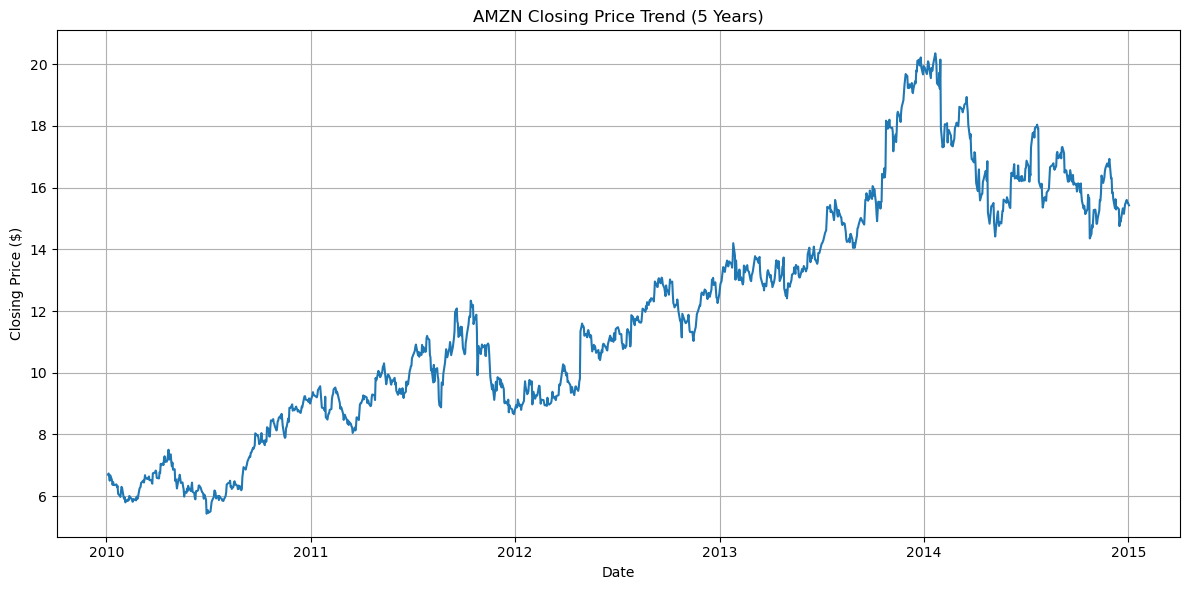

In [199]:
import matplotlib.pyplot as plt
start_date = df_new2['Date'].min()
end_date = start_date + pd.DateOffset(years=5)

amzn_5yr = df_new2[(df_new2['Date'] >= start_date) & (df_new2['Date'] < end_date)]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(amzn_5yr['Date'], amzn_5yr['Close'])

plt.title('AMZN Closing Price Trend (5 Years)')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Plot a bar chart of total trading volume per year and annotate each bar with the exact volume value

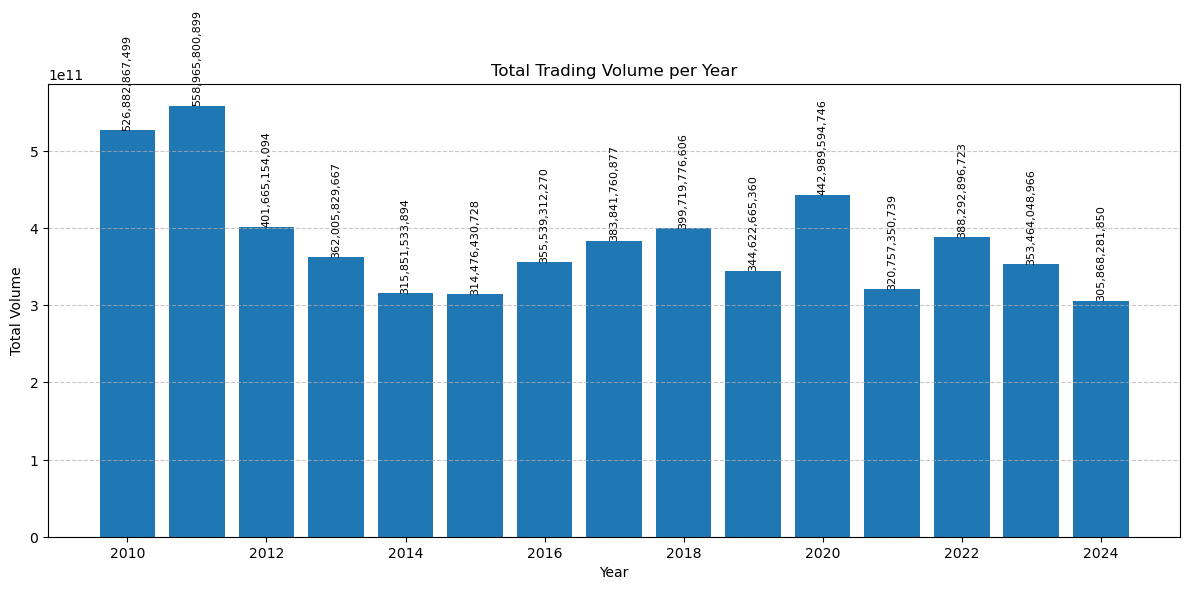

In [200]:
# Total trading volume per year
yearly_volume = df.groupby('Year')['Volume'].sum()

# Convert to arrays (NumPy)
years = yearly_volume.index.to_numpy()
volumes = yearly_volume.values

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(years, volumes)

# Annotate each bar with exact volume
for bar, volume in zip(bars, volumes):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{volume:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.title('Total Trading Volume per Year')
plt.xlabel('Year')
plt.ylabel('Total Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Plot a heatmap showing the correlation between open, high, low, close, and volume columns

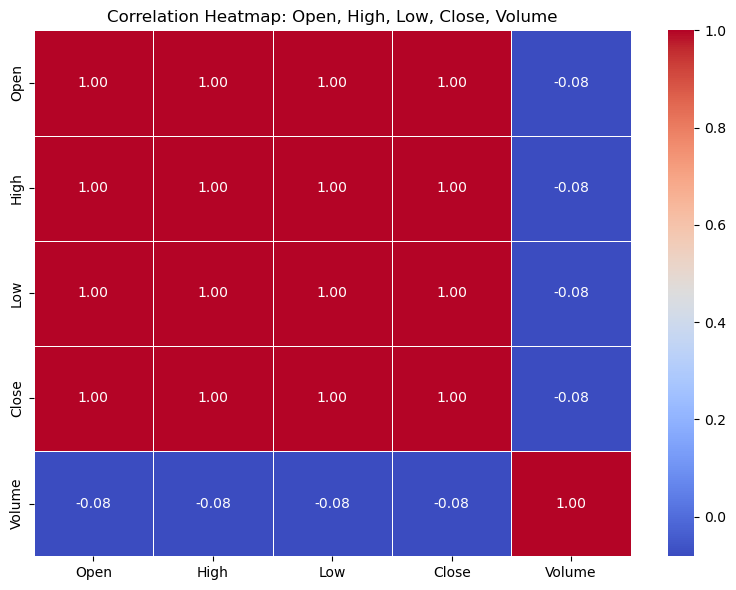

In [202]:
import seaborn as sns

# Select relevant columns
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,      # show correlation values
    cmap='coolwarm', # color scheme
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap: Open, High, Low, Close, Volume')
plt.tight_layout()
plt.show()

### Plot a boxplot of AMZN closing prices by year to visualize price spread and outliers each year

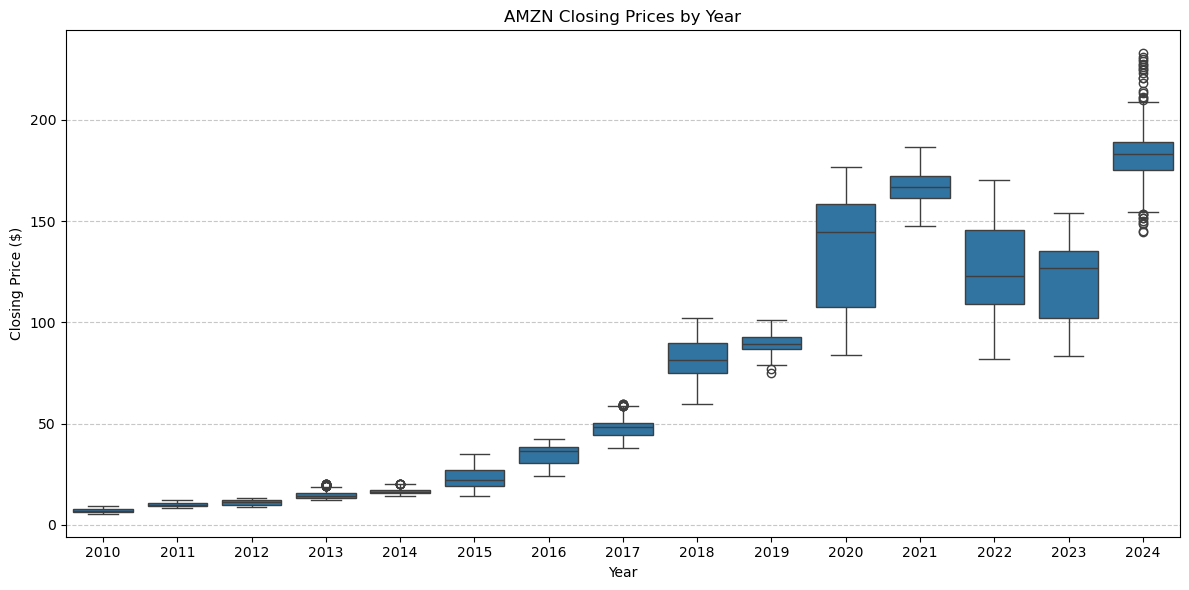

In [203]:
import seaborn as sns
import matplotlib.pyplot as plt

amzn = df[df['Symbol'] == 'AMZN']

plt.figure(figsize=(12, 6))
sns.boxplot(data=amzn, x='Year', y='Close')

plt.title('AMZN Closing Prices by Year')
plt.xlabel('Year')
plt.ylabel('Closing Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()